# AlphaEvolve on Google Cloud, run it yourself

Give a naive function a scoring function, and let a Gemini ensemble evolve it into something better. In this notebook you run the exact circle packing demo from the episode, watch the score climb, and then change the seed yourself to see what moves.

One honest note up front. AlphaEvolve is not new, it is DeepMind research from 2025, the system famous for a faster matrix multiplication. What is new is that it went generally available on Google Cloud with an open source client library, so you can finally run it on your own code. It is already in production, Google reports using it to cut Spanner write amplification by 20 percent, and early users like JetBrains and Schrodinger report real speedups. Those are their results, we produce our own below.

📺 Watch the build: [EPISODE VIDEO LINK]

💻 Code and skill: https://github.com/SaschaHeyer/gen-ai-livestream/tree/main/alphaevolve

> **What you need.** AlphaEvolve rides on a Gemini Enterprise license, any tier including a trial, and you point it at your own Gemini Enterprise app (the engine id). Without one, the cloud cells will not run for you, but every one below carries its real saved output so you can read along and see exactly what a run looks like. My honest take, this is a developer API and really belongs on Vertex AI with pay per use, not behind an enterprise seat, but that is a packaging call, not a technical one.

## Setup

The client library is not on PyPI, it installs from Google's repo. We pin the exact commit so the install stays reproducible.

In [1]:
# The alpha_evolve client library, pinned to a known commit, plus the few extras the demo needs.
# The git install pulls google-auth, requests, and pydantic with it and takes a minute or two.
!pip install -q "git+https://github.com/Google-Cloud-AI/alphaevolve-on-googlecloud.git@65030fd"
!pip install -q nest_asyncio numpy matplotlib python-dotenv

zsh:1: command not found: pip


zsh:1: command not found: pip


### Authenticate and point at your project

The client uses Application Default Credentials. In Colab one line signs you in and sets them up. Then tell it your project and your Gemini Enterprise engine id.

In [2]:
import os
try:
    from google.colab import auth
    auth.authenticate_user()  # Colab, this sets Application Default Credentials
except ImportError:
    pass  # outside Colab, run: gcloud auth application-default login

try:
    from google.colab import userdata
    PROJECT_ID = userdata.get('PROJECT_ID')
    GE_APP_ID = userdata.get('GE_APP_ID')
except Exception:
    PROJECT_ID = os.environ.get('PROJECT_ID', 'your-gcp-project')
    GE_APP_ID = os.environ.get('GE_APP_ID', 'your-gemini-enterprise-engine-id')

print('Configured, project set:', PROJECT_ID != 'your-gcp-project')

Configured, project set: True


## 1. Mark the code to evolve, and score it

Think of it like handing a sculptor a block of clay but taping off the parts you want left alone. You wrap the region AlphaEvolve is allowed to rewrite in two comment markers, and it never touches anything outside them.

Our seed is the classic circle packing problem, pack 26 circles into a unit square and maximize the sum of their radii, the exact problem from the AlphaEvolve paper. Here is the full seed program, the evolvable region is between the EVOLVE-BLOCK markers.

In [3]:
SEED_PROGRAM = r'''# Copyright 2026 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
# pylint: disable=g-import-not-at-top
# pylint: disable=g-bad-import-order
# pylint: disable=pointless-string-statement
from typing import Any, Mapping

# EVOLVE-BLOCK-START
"""Constructor-based circle packing for n=26 circles"""
import numpy as np


def construct_packing(n, random_seed: int):
    """Construct a specific arrangement of 26 circles in a unit square.

    The goal is to maximize the sum of their radii.

    Args:
        n: Number of circles.
        random_seed: Random seed for reproducibility.

    Returns:
        Tuple of (centers, radii, sum_of_radii)
        centers: np.array of shape (26, 2) with (x, y) coordinates
        radii: np.array of shape (26) with radius of each circle
        sum_of_radii: Sum of all radii
    """

    rng = np.random.default_rng(random_seed)
    centers = np.zeros((n, 2))

    # Place circles in a structured pattern
    # This is a simple pattern - evolution will improve this

    # First, place a large circle in the center
    centers[0] = [0.5, 0.5]

    # Place 8 circles around it in a ring
    for i in range(8):
        angle = 2 * np.pi * i / 8
        centers[i + 1] = [0.5 + 0.3 * np.cos(angle), 0.5 + 0.3 * np.sin(angle)]

    # Place 16 more circles in an outer ring
    for i in range(16):
        angle = 2 * np.pi * i / 16 * rng.uniform(0.9, 1.1)
        centers[i + 9] = [0.5 + 0.7 * np.cos(angle), 0.5 + 0.7 * np.sin(angle)]

    # Additional positioning adjustment to make sure all circles
    # are inside the square and don't overlap
    # Clip to ensure everything is inside the unit square
    centers = np.clip(centers, 0.01, 0.99)

    # Compute maximum valid radii for this configuration
    radii = compute_max_radii(centers, random_seed)

    # Calculate the sum of radii
    sum_radii = np.sum(radii)

    return centers, radii, sum_radii


def compute_max_radii(centers, random_seed: int):
    """Compute the maximum possible radii for each circle position.

    Make sure that they don't overlap and stay within the unit square.

    Args:
        centers: np.array of shape (n, 2) with (x, y) coordinates
        random_seed: Random seed for reproducibility.

    Returns:
        np.array of shape (n) with radius of each circle
    """
    del random_seed  # Unused.
    n = centers.shape[0]
    radii = np.ones(n)

    # First, limit by distance to square borders
    for i in range(n):
        x, y = centers[i]
        # Distance to borders
        radii[i] = min(x, y, 1 - x, 1 - y)

    # Then, limit by distance to other circles
    # Each pair of circles with centers at distance d can have
    # sum of radii at most d to avoid overlap
    for i in range(n):
        for j in range(i + 1, n):
            dist = np.sqrt(np.sum((centers[i] - centers[j]) ** 2))

            # If current radii would cause overlap
            if radii[i] + radii[j] > dist:
                # Scale both radii proportionally
                scale = dist / (radii[i] + radii[j] + 1e-7)
                radii[i] *= scale
                radii[j] *= scale

    return radii


# EVOLVE-BLOCK-END


def _circles_overlap(centers, radii):
    """Protected function to compute max radii."""
    n = centers.shape[0]

    for i in range(n):
        for j in range(i + 1, n):
            dist = np.sqrt(np.sum((centers[i] - centers[j]) ** 2))
            if radii[i] + radii[j] > dist:
                return True

    return False


def evaluate(eval_inputs: Mapping[str, Any]) -> dict[str, float]:
    """Construct a packing and evaluate its score."""
    n = eval_inputs["n"]
    if "random_seed" not in eval_inputs:
        random_seed = 42
    else:
        random_seed = eval_inputs["random_seed"]
    centers, radii, _ = construct_packing(n, random_seed=random_seed)
    if (
        centers.shape != (n, 2)
        or not np.isfinite(centers).all()
        or not ((radii[:, None] <= centers) & (centers <= 1 - radii[:, None])).all()
    ):
        return {"sum_of_radii": -np.inf}

    if radii.shape != (n,) or not np.isfinite(radii).all() or not (0 <= radii).all():
        return {"sum_of_radii": -np.inf}

    if _circles_overlap(centers, radii):
        return {"sum_of_radii": -np.inf}

    return {"sum_of_radii": float(np.sum(radii))}'''

print(SEED_PROGRAM[:400], '...')

# Copyright 2026 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WI ...


The other half is the scoring function. That `evaluate()` at the bottom returns `sum_of_radii`, the number AlphaEvolve tries to make bigger. This is you telling it what better means, and it is the whole game, a lazy scorer gets you lazy evolution.

Let's run the seed once locally to get our baseline.

In [4]:
import numpy as np
ns = {'np': np, 'Any': object, 'Mapping': dict}
exec(SEED_PROGRAM, ns)
baseline = ns['evaluate']({'n': 26})['sum_of_radii']
print(f'Seed baseline sum_of_radii = {baseline:.4f}')

Seed baseline sum_of_radii = 0.9415


Notice the number, around 0.94. That loose ring of circles leaves a lot of empty space. Now let's see what AlphaEvolve does with it.

## 2. Kick off the evolution

This is evolutionary search, Darwin pointed at your code. AlphaEvolve asks a Gemini ensemble for variations of the marked region, runs your scorer on each candidate, keeps the winners, and breeds the next generation from them.

We wire three things together, a client pointed at your engine, an experiment that carries your evaluator, and the controller loop that drives it.

In [5]:
import asyncio, nest_asyncio, logging
from alpha_evolve.client import AlphaEvolveClient
from alpha_evolve.controller import run_controller_loop
from alpha_evolve.experiment import AlphaEvolveExperiment
from alpha_evolve.models import (AlphaEvolveEvaluationInsight, AlphaEvolveEvaluationInsights,
    AlphaEvolveEvaluationScore, AlphaEvolveEvaluationScores, AlphaEvolveProgramEvaluation)
from alpha_evolve.visualization import get_score

logging.getLogger('alpha_evolve').setLevel(logging.WARNING)  # keep the output clean
METRIC = 'sum_of_radii'
FAILED = -1e12  # the sentinel score for a broken candidate

def evaluate_candidate(candidate):
    code = candidate['content']['files'][0]['content']
    score, insights = FAILED, []
    try:
        ns = {'np': np, 'Any': object, 'Mapping': dict}
        exec(code, ns)
        r = ns['evaluate']({'n': 26}).get(METRIC)
        if r is not None and r != -float('inf'):
            score = float(r)
        else:
            insights.append(AlphaEvolveEvaluationInsight(label='Invalid', text='constraint broken'))
    except Exception as e:
        insights.append(AlphaEvolveEvaluationInsight(label='Runtime Error', text=str(e)))
    scores = AlphaEvolveEvaluationScores(scores=[AlphaEvolveEvaluationScore(metric=METRIC, score=score)])
    ev = AlphaEvolveProgramEvaluation(scores=scores, insights=AlphaEvolveEvaluationInsights(insights=insights)) if insights else AlphaEvolveProgramEvaluation(scores=scores)
    return ev.model_dump()

> **Sharp edge, the scorer is your real work.** Everything above is boilerplate you copy once. The `evaluate_candidate` wrapper just runs each candidate and reports its score, the intelligence you add lives in what you decide to measure.

In [6]:
MAX_PROGRAMS = 12  # your search budget. Bigger finds more but costs more Gemini calls and time.

client = AlphaEvolveClient(project_id=PROJECT_ID, location='global',
    collection='default_collection', engine=GE_APP_ID, assistant='default_assistant',
    base_url='discoveryengine.googleapis.com')
experiment = AlphaEvolveExperiment(client, evaluate_candidate, MAX_PROGRAMS)
experiment.create_experiment({
    'title': 'Circle Packing', 'program_language': 'python',
    'problem_description': 'Evolve the marked region to maximize the sum of radii.',
    'run_settings': {'max_programs': MAX_PROGRAMS, 'concurrency': 4},
    'generation_settings': {'models': [
        {'name': 'gemini-3.5-flash', 'weight': 0.7},
        {'name': 'gemini-3.1-pro-preview', 'weight': 0.3}]}})
experiment.create_initial_program({
    'content': {'files': [{'path': 'program.py', 'content': SEED_PROGRAM}]},
    'evaluation': {'scores': {'scores': [{'metric': METRIC, 'score': FAILED}]}}})
experiment.start_experiment()

nest_asyncio.apply()
asyncio.run(run_controller_loop(experiment))
print('Evolution finished.')

No new candidates for 120s and queue is empty; assuming the backend has finished. Stopping at 11/12 programs evaluated.


Evolution finished.


> **Sharp edge, progress is non-monotonic, do not panic.** The score does not climb smoothly. A candidate hits a great value, the next one crashes, then it jumps again, like a hiker walking downhill to reach a taller peak. Broken candidates come back with a big negative sentinel and are a signal, not a failure. Also, the loop can stop a candidate or two short of your budget when the backend goes idle, that is normal.

Let's read back every program the run produced, in the order they were scored, so you can see the climb for yourself.

In [7]:
resp = experiment.list_programs(params={'order_by': f'{METRIC} desc'})
progs = resp.get('alphaEvolvePrograms', []) if resp else []
scored = [(get_score(p, METRIC), p) for p in progs]
valid = sorted([(s, p) for s, p in scored if s > FAILED/2], key=lambda x: x[0], reverse=True)
print(f'{len(progs)} candidates, baseline was {baseline:.4f}\n')
for i, (s, p) in enumerate(valid[:5]):
    print(f'  rank {i+1}: sum_of_radii = {s:.4f}')
best_score, best = valid[0]
print(f'\nBest = {best_score:.4f}  vs seed {baseline:.4f}  ({best_score/baseline:.2f}x)')

12 candidates, baseline was 0.9415

  rank 1: sum_of_radii = 2.4524
  rank 2: sum_of_radii = 2.1785
  rank 3: sum_of_radii = 2.1285
  rank 4: sum_of_radii = 2.0818
  rank 5: sum_of_radii = 1.7839

Best = 2.4524  vs seed 0.9415  (2.60x)


## 3. See the difference

The number is one thing, the picture makes it obvious. Left is the seed, a loose ring. Right is the program AlphaEvolve evolved, packed tight.

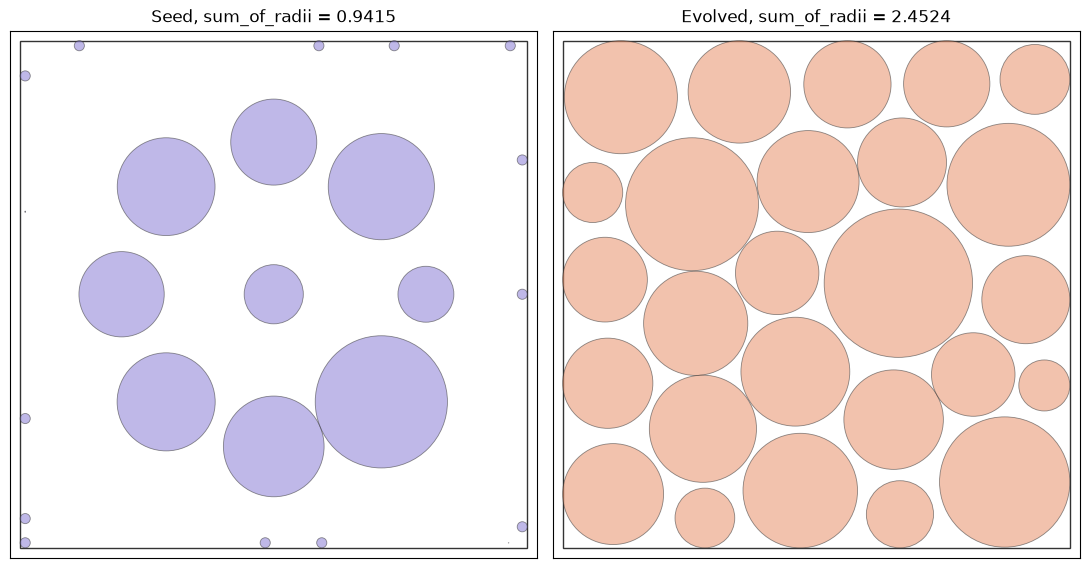

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt, matplotlib.patches as patches

def packing(program_code):
    ns = {'np': np, 'Any': object, 'Mapping': dict}
    exec(program_code, ns)
    return ns['construct_packing'](26, 42)

sc, sr, ss = packing(SEED_PROGRAM)
ec, er, es = packing(best['content']['files'][0]['content'])
fig, axes = plt.subplots(1, 2, figsize=(11, 5.6))
for ax, (c, r, s, t, col) in zip(axes, [(sc,sr,ss,'Seed','#8b7fd6'), (ec,er,es,'Evolved','#e8916b')]):
    ax.add_patch(patches.Rectangle((0,0),1,1,fill=False,ec='#333'))
    for (x,y),rad in zip(c,r): ax.add_patch(patches.Circle((x,y),rad,alpha=0.55,fc=col,ec='#333',lw=0.6))
    ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.02); ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{t}, sum_of_radii = {s:.4f}')
plt.tight_layout(); plt.show()

## Your turn

The lesson of AlphaEvolve is that the seed and the scorer are yours to shape. These two exercises are local and instant, no cloud call, they build the intuition before you spend a real run.

**Your turn 1.** The seed is hand-written and not very good. Change the outer ring radius in `construct_packing` (the `0.7` factor) and see how the baseline moves. A better starting point changes where evolution begins.

In [9]:
# Edit the 0.7 below to something like 0.8, run this cell, and watch the baseline change.
tweaked = SEED_PROGRAM.replace('0.7 * np.cos', '0.8 * np.cos').replace('0.7 * np.sin', '0.8 * np.sin')
ns = {'np': np, 'Any': object, 'Mapping': dict}
exec(tweaked, ns)
print('tweaked baseline:', round(ns['evaluate']({'n': 26})['sum_of_radii'], 4))
# To evolve YOUR tweaked seed, set SEED_PROGRAM = tweaked and re-run the evolution cell above.

tweaked baseline: 0.9111


**Your turn 2.** The seed's outer ring is placed with a random seed, so the starting point is not even deterministic. Try a few and watch the baseline wiggle. Then think about what other metric you would optimize if this were your own code.

In [10]:
for rs in (0, 7, 42, 100):
    ns = {'np': np, 'Any': object, 'Mapping': dict}
    exec(SEED_PROGRAM, ns)
    score = ns['evaluate']({'n': 26, 'random_seed': rs})['sum_of_radii']
    print(f'random_seed={rs:>3}  seed sum_of_radii = {score:.4f}')

random_seed=  0  seed sum_of_radii = 0.9734
random_seed=  7  seed sum_of_radii = 0.9675
random_seed= 42  seed sum_of_radii = 0.9415
random_seed=100  seed sum_of_radii = 0.9798


## Solutions

One worked answer per exercise.

**Solution 1.** A wider outer ring (0.8) spreads the circles out, which usually lifts the seed baseline a little because the border-limited radii grow. The exact number depends on the value you pick, the point is that the seed is a lever, not a fixed starting line.

**Solution 2.** The baseline moves with the random seed because the outer ring is placed stochastically, the seed program is a rough starting point, not a careful one. That is the point of evolution, AlphaEvolve fixes the seed and evolves structure, not luck. If you cared about packing density instead of summed radii you would return a different number from `evaluate`, and AlphaEvolve would evolve toward a completely different arrangement.

## Take it home

Install the whole workflow as an agent skill, so your own agent can wrap a function, write a scorer, and drive a run for you.

In [ ]:
!npx skills add https://github.com/SaschaHeyer/gen-ai-livestream/tree/main/alphaevolve/skill

Read the full write-up: [ARTICLE LINK]

You made it to the end. If you build something with this, I would love to hear about it.

* Connect on [LinkedIn](https://www.linkedin.com/in/saschaheyer/)
* Subscribe on [YouTube](https://www.youtube.com/@ml-engineer) ❤️